In [23]:
import pandas as pd

# Population Analysis
Reading and merging the scraped country and region data.

In [51]:
countries = pd.read_csv("countries.csv")
regions = pd.read_csv("regions.csv")
countries.head()

,rank,country,population,yearly_change,net_change,density,land_area,migrants,fertility_rate,median_age,urban_pop,world_share
0,1,India,"1,476,625,576",0.87%,"12,760,051",497,"2,973,190","−440,456",1.93,29.2,37.6%,17.8%
1,2,China,"1,412,914,089",−0.22%,"−3,182,005",150,"9,388,211","−232,107",1.03,40.6,68.7%,17%
2,3,United States,"349,035,494",0.51%,"1,759,687",38,"9,147,420","1,177,848",1.63,38.7,83.1%,4.2%
3,4,Indonesia,"287,886,782",0.76%,"2,165,546",159,"1,811,570","−39,472",2.08,30.7,60.3%,3.5%
4,5,Pakistan,"259,299,791",1.6%,"4,080,237",336,"770,880","−1,144,738",3.44,20.8,34.7%,3.1%


Checking whether any country names fail to match between the two CSVs before we merge them 

In [52]:
countries_set = set(countries["country"])
regions_set = set(regions["country"])
countries_set - regions_set

{'Brunei',
 'Czech Republic (Czechia)',
 'Hong Kong',
 'Macao',
 'North Macedonia',
 'Saint Barthelemy',
 'Saint Kitts & Nevis',
 'Saint Pierre & Miquelon',
 'Sao Tome & Principe',
 'St. Vincent & Grenadines',
 'Turks and Caicos',
 'U.S. Virgin Islands',
 'Wallis & Futuna'}

Rename and merge

In [53]:
renames = {"Czech Republic (Czechia)": "Czechia",
    "Hong Kong": "China, Hong Kong SAR",
    "Macao": "China, Macao SAR",
    "North Macedonia": "Republic of North Macedonia",
    "Brunei": "Brunei Darussalam",
    "Saint Barthelemy": "Saint Barthélemy",
    "Saint Kitts & Nevis": "Saint Kitts and Nevis",
    "Saint Pierre & Miquelon": "Saint Pierre and Miquelon",
    "Sao Tome & Principe": "Sao Tome and Principe",
    "St. Vincent & Grenadines": "Saint Vincent and the Grenadines",
    "Turks and Caicos": "Turks and Caicos Islands",
    "U.S. Virgin Islands": "United States Virgin Islands",
    "Wallis & Futuna": "Wallis and Futuna Islands",
  }
for old_name, new_name in renames.items():
    countries.loc[countries["country"] == old_name, "country"] = new_name

Check: returns set() if everything is good

In [54]:
countries_set = set(countries["country"])
regions_set = set(regions["country"])
countries_set - regions_set

set()

# merge

In [55]:
data = pd.merge(countries, regions, on="country")
data.head()

,rank,country,population,yearly_change,net_change,density,land_area,migrants,fertility_rate,median_age,urban_pop,world_share,continent
0,1,India,"1,476,625,576",0.87%,"12,760,051",497,"2,973,190","−440,456",1.93,29.2,37.6%,17.8%,Asia
1,2,China,"1,412,914,089",−0.22%,"−3,182,005",150,"9,388,211","−232,107",1.03,40.6,68.7%,17%,Asia
2,3,United States,"349,035,494",0.51%,"1,759,687",38,"9,147,420","1,177,848",1.63,38.7,83.1%,4.2%,Northern America
3,4,Indonesia,"287,886,782",0.76%,"2,165,546",159,"1,811,570","−39,472",2.08,30.7,60.3%,3.5%,Asia
4,5,Pakistan,"259,299,791",1.6%,"4,080,237",336,"770,880","−1,144,738",3.44,20.8,34.7%,3.1%,Asia


Clean - commas, percent signs, or theminus sign. Converting to real numbers so we can do math

In [56]:
def clean_number(text):
    text = text.replace(",", "")
    text = text.replace("%", "")
    text = text.replace("−", "-")
    text = text.replace("–", "nan")
    return text
  
  
data["population"] = [int(clean_number(value)) for value in data["population"]]
data["yearly_change"] = [float(clean_number(value)) for value in data["yearly_change"]]
data["net_change"] = [int(clean_number(value)) for value in data["net_change"]]
data["land_area"] = [int(clean_number(value)) for value in data["land_area"]]
data["migrants"] = [int(clean_number(value)) for value in data["migrants"]]
data["urban_pop"] = [float(clean_number(value)) for value in data["urban_pop"]]
data["world_share"] = [float(clean_number(value)) for value in data["world_share"]]
data["density"] = [int(clean_number(value)) for value in data["density"]]
data.head()

,rank,country,population,yearly_change,net_change,density,land_area,migrants,fertility_rate,median_age,urban_pop,world_share,continent
0,1,India,1476625576,0.87,12760051,497,2973190,-440456,1.93,29.2,37.6,17.8,Asia
1,2,China,1412914089,-0.22,-3182005,150,9388211,-232107,1.03,40.6,68.7,17.0,Asia
2,3,United States,349035494,0.51,1759687,38,9147420,1177848,1.63,38.7,83.1,4.2,Northern America
3,4,Indonesia,287886782,0.76,2165546,159,1811570,-39472,2.08,30.7,60.3,3.5,Asia
4,5,Pakistan,259299791,1.60,4080237,336,770880,-1144738,3.44,20.8,34.7,3.1,Asia


In [60]:
continent_averages = data.groupby("continent")[["density", "fertility_rate", "median_age", "urban_pop"]].mean()
continent_averages

,density,fertility_rate,median_age,urban_pop
continent,,,,
Africa,136.965517,3.591897,21.846552,49.764912
Asia,1055.843137,2.057843,31.323529,60.545833
Europe,813.510638,1.461277,43.334043,72.013636
Latin America and the Caribbean,200.560000,1.738800,35.168000,65.673171
Northern America,271.000000,1.512000,41.800000,86.875000
Oceania,130.391304,2.508696,29.147826,55.425000


In [61]:
for column in ["density", "fertility_rate", "median_age", "urban_pop"]:
    top = continent_averages.sort_values(column, ascending=False).head(1)
    print(column)
    print(top)

density
               density  fertility_rate  median_age  urban_pop
continent                                                    
Asia       1055.843137        2.057843   31.323529  60.545833
fertility_rate
              density  fertility_rate  median_age  urban_pop
continent                                                   
Africa     136.965517        3.591897   21.846552  49.764912
median_age
              density  fertility_rate  median_age  urban_pop
continent                                                   
Europe     813.510638        1.461277   43.334043  72.013636
urban_pop
                  density  fertility_rate  median_age  urban_pop
continent                                                       
Northern America    271.0           1.512        41.8     86.875


Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='continent'>

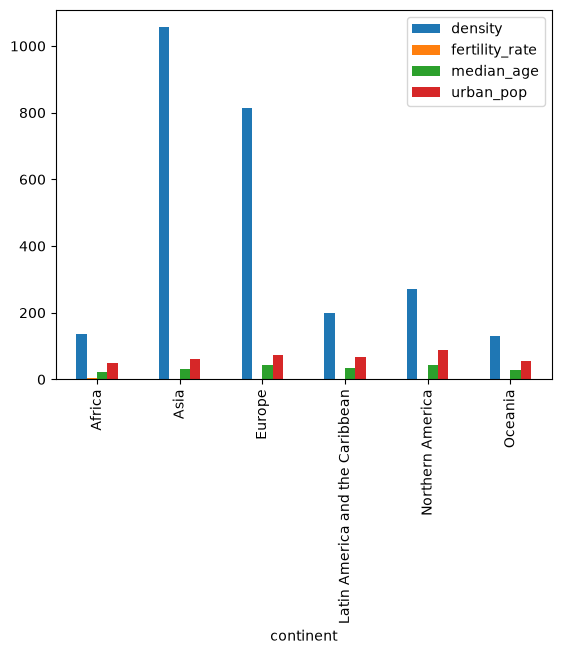

In [63]:
continent_averages.plot.bar()